# V2 Label 产物讲解 + QA 质量检查

本 notebook 覆盖两件事：

1. **讲解** `artifacts/label_engineering/v2/` 里三张 V2 表的字段与含义；
2. **QA**：按 V2 方案 §14 的单元测试 + §15 的分布检查，对真实产物跑一遍自动断言，输出 PASS/FAIL。

数据源已补齐到 2010-2025，V2 已修复时间窗口、报告/面板分离、独立有效标志、盈亏迁移、训练期阈值等。


In [3]:
import pandas as pd
import numpy as np
import json
import hashlib
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 26)

BASE = "/home/intern_fjq_2026/Projects/chinese-wwm-roberta/label_engineering"
V2 = BASE + "/v2"
meta = json.load(open(V2 + "/label_metadata_v2.json", encoding="utf-8"))
snap = pd.read_parquet(V2 + "/consensus_snapshot_monthly_v2.parquet")
rev  = pd.read_parquet(V2 + "/revision_label_monthly_v2.parquet")
rep  = pd.read_parquet(V2 + "/report_label_detail_v2.parquet")
rep_raw = pd.read_parquet(V2 + "/clean_report_v2.parquet")
org_daily = pd.read_parquet(V2 + "/org_daily_forecast_v2.parquet")

print("=== V2 关键元数据 ===")
for k in ["label_version", "metric", "label_window", "source_window", "fy_range",
          "lookback_days", "target_horizon_months", "train_period"]:
    print("  %-26s = %s" % (k, meta[k]))
print("  %-26s = %s" % ("flat_threshold", meta["flat_threshold"]))
print("  %-26s = %s" % ("strong_threshold_fitted", meta["strong_threshold_fitted"]))
print("  %-26s = %s" % ("near_zero_threshold", meta["near_zero_threshold"]))


=== V2 关键元数据 ===
  label_version              = v2.0
  metric                     = FORECAST_NP
  label_window               = ['2024-01-31', '2024-12-31']
  source_window              = ['2023-07-01', '2025-03-31']
  fy_range                   = [2024, 2026]
  lookback_days              = 180
  target_horizon_months      = [1, 3]
  train_period               = asof_month <= 2024-06-30
  flat_threshold             = {'1': 0.01, '3': 0.02}
  strong_threshold_fitted    = {'1m_fy0': 0.092022, '1m_fy1': 0.08912, '1m_fy2': 0.040938, '3m_fy0': 0.199187, '3m_fy1': 0.194675, '3m_fy2': 0.104503}
  near_zero_threshold        = {'0': 381.0, '1': 494.0, '2': 633.0}


## 1. 三张 V2 表总览


In [4]:
print("=== 规模 ===")
for name, d in [("consensus_snapshot_monthly_v2", snap),
                ("revision_label_monthly_v2", rev),
                ("report_label_detail_v2", rep)]:
    print("  %-30s %d 行 × %d 列" % (name, d.shape[0], d.shape[1]))

print("\n=== 快照列 ===")
print(snap.columns.tolist())
print("\n=== 修正列 ===")
print(rev.columns.tolist())
print("\n=== 报告列 ===")
print(rep.columns.tolist())


=== 规模 ===
  consensus_snapshot_monthly_v2  97486 行 × 31 列
  revision_label_monthly_v2      194972 行 × 44 列
  report_label_detail_v2         257916 行 × 33 列

=== 快照列 ===
['stock_code', 'stock_name', 'fy', 'forecast_horizon', 'asof_month', 'metric', 'consensus_median', 'consensus_mean', 'consensus_trimmed_mean', 'forecast_min', 'forecast_max', 'mad', 'iqr', 'dispersion_robust', 'consensus_strength', 'consensus_strength_classifiable', 'n_org', 'forecast_age_median', 'forecast_age_p90', 'stale_ratio', 'profit_state', 'near_zero_threshold', 'scale_floor', 'history_window_complete', 'left_censored', 'snapshot_valid', 'snapshot_invalid_reason', 'strength_threshold_q30', 'strength_threshold_q70', 'strength_threshold_version', 'label_version']

=== 修正列 ===
['stock_code', 'fy', 'forecast_horizon', 'asof_month', 'target_month', 'target_horizon_months', 'metric', 'consensus_t', 'consensus_future', 'revision_consensus_pct_raw', 'revision_consensus_symmetric_raw', 'revision_consensus_pct', 'revisio

## 2. 共识快照 `consensus_snapshot_monthly_v2`

每行 = (股票 × 被预测财年 FY × 月末时点 × FORECAST_NP) 的一致预期快照，是**当前状态特征**。

V2 相比 V1 新增：`forecast_min/max`、`consensus_strength_classifiable`、`near_zero_threshold/scale_floor`、`history_window_complete/left_censored`、`snapshot_invalid_reason`、强度阈值字段。


In [5]:
snap.head(6)

,stock_code,stock_name,fy,forecast_horizon,asof_month,metric,consensus_median,consensus_mean,consensus_trimmed_mean,forecast_min,forecast_max,mad,iqr,dispersion_robust,consensus_strength,consensus_strength_classifiable,n_org,forecast_age_median,forecast_age_p90,stale_ratio,profit_state,near_zero_threshold,scale_floor,history_window_complete,left_censored,snapshot_valid,snapshot_invalid_reason,strength_threshold_q30,strength_threshold_q70,strength_threshold_version,label_version
0,000001,平安银行,2024,0,2024-01-31,FORECAST_NP,5467900.0,5.490798e+06,5.452591e+06,5084350.568,6183100.000,165650.000,294351.11025,0.044915,moderate_consensus,1,28,98.0,150.3,0.000000,profit,381.0,381.0,1,0,1,None,0.037536,0.097637,train_2024H1_per_horizon,v2.0
1,000001,平安银行,2025,1,2024-01-31,FORECAST_NP,6166800.0,6.149433e+06,6.102335e+06,5433657.095,7173000.000,316800.000,543575.00000,0.076164,moderate_consensus,1,26,98.0,152.5,0.000000,profit,494.0,494.0,1,0,1,None,0.048489,0.113176,train_2024H1_per_horizon,v2.0
2,000002,万科Ａ,2024,0,2024-01-31,FORECAST_NP,2146000.0,2.098077e+06,2.101987e+06,1722100.000,2417000.000,148300.000,391700.00000,0.102456,weak_consensus,1,25,93.0,122.0,0.000000,profit,381.0,381.0,1,0,1,None,0.037536,0.097637,train_2024H1_per_horizon,v2.0
3,000002,万科Ａ,2025,1,2024-01-31,FORECAST_NP,2246100.0,2.193795e+06,2.207027e+06,1633400.000,2583600.000,191780.000,379400.00000,0.126590,weak_consensus,1,25,93.0,122.0,0.000000,profit,494.0,494.0,1,0,1,None,0.048489,0.113176,train_2024H1_per_horizon,v2.0
4,000012,南玻A,2024,0,2024-01-31,FORECAST_NP,226100.0,2.172228e+05,2.172228e+05,194700.000,239513.984,13413.984,32600.00000,0.087959,moderate_consensus,1,5,146.0,151.4,0.166667,profit,381.0,381.0,1,0,1,None,0.037536,0.097637,train_2024H1_per_horizon,v2.0
5,000012,南玻A,2025,1,2024-01-31,FORECAST_NP,252900.0,2.587490e+05,2.587490e+05,236100.000,288645.058,16800.000,34900.00000,0.098488,moderate_consensus,1,5,146.0,151.4,0.000000,profit,494.0,494.0,1,0,1,None,0.048489,0.113176,train_2024H1_per_horizon,v2.0


In [13]:
snap.loc[(snap['n_org'] >= 20) & (snap['forecast_horizon'] == 2), 'stock_code'].nunique()

435

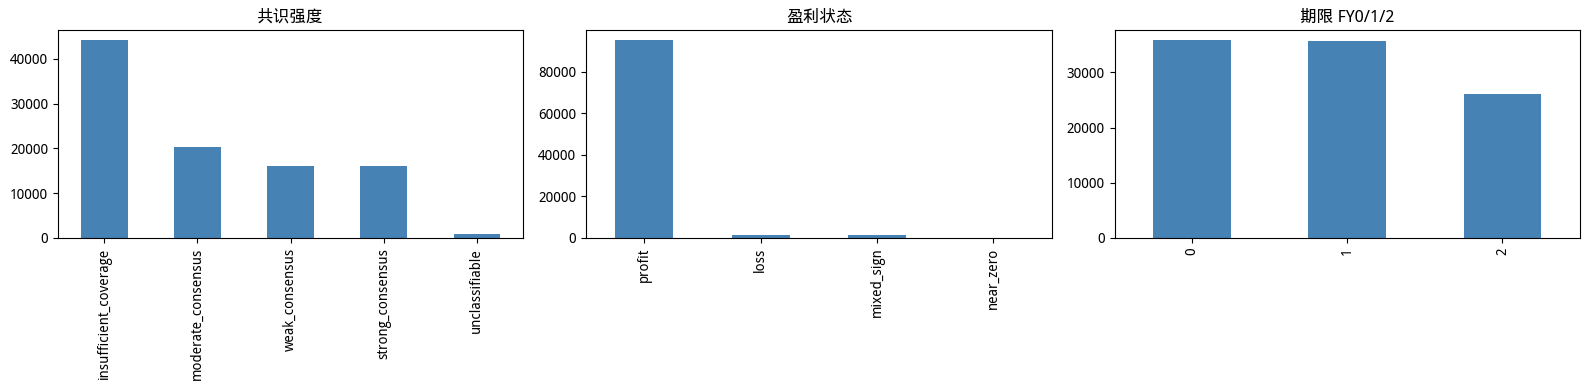

snapshot_valid: {1: 53339, 0: 44147}
snapshot_invalid_reason: {None: 53339, 'insufficient_current_coverage': 44147}
left_censored: {0: 97486}


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
snap["consensus_strength"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue"); axes[0].set_title("共识强度")
snap["profit_state"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue"); axes[1].set_title("盈利状态")
snap["forecast_horizon"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="steelblue"); axes[2].set_title("期限 FY0/1/2")
plt.tight_layout(); plt.show()

print("snapshot_valid:", snap["snapshot_valid"].value_counts().to_dict())
print("snapshot_invalid_reason:", snap["snapshot_invalid_reason"].value_counts(dropna=False).to_dict())
print("left_censored:", snap["left_censored"].value_counts().to_dict())


## 3. 未来修正 `revision_label_monthly_v2`

每行 = (股票 × FY × 月末 asof × 期限 1m/3m)，是**未来目标（要预测的 y）**。

V2 关键点：
- `*_raw` 是诊断连续值；正式目标(`*_pct`/`*_class`)只在有效时非空；
- 四个目标各有独立 valid：`revision_consensus/fixed/active/breadth_valid`；
- 普通五分类只对「盈利→盈利」样本；转盈/转亏/亏损收窄等走 `profit_transition_class`；
- `invalid_reason` 标准化：right/future_snapshot_missing/insufficient_* 等。


In [5]:
cols_main = ["stock_code", "fy", "asof_month", "target_horizon_months", "consensus_t",
             "consensus_future", "revision_consensus_pct", "revision_consensus_class",
             "revision_consensus_valid", "invalid_reason"]
rev[cols_main].head(8)


,stock_code,fy,asof_month,target_horizon_months,consensus_t,consensus_future,revision_consensus_pct,revision_consensus_class,revision_consensus_valid,invalid_reason
0,000001,2024,2024-01-31,1,5467900.000,5403400.000,-0.011796,down,1,None
1,000001,2025,2024-01-31,1,6166800.000,5968200.000,-0.032205,down,1,None
2,000002,2024,2024-01-31,1,2146000.000,2146000.000,0.000000,flat,1,None
3,000002,2025,2024-01-31,1,2246100.000,2246100.000,0.000000,flat,1,None
4,000012,2024,2024-01-31,1,226100.000,227650.000,NaN,None,0,insufficient_future_co...
5,000012,2025,2024-01-31,1,252900.000,264200.000,NaN,None,0,insufficient_future_co...
6,000021,2024,2024-01-31,1,97808.509,97808.509,NaN,None,0,insufficient_current_c...
7,000021,2025,2024-01-31,1,111900.000,111900.000,NaN,None,0,insufficient_current_c...


In [6]:
cols_aux = ["revision_fixed_pct", "revision_fixed_valid", "revision_active_pct",
            "revision_active_valid", "revision_breadth", "breadth_valid",
            "profit_transition_class", "n_org_fixed", "n_active_update",
            "left_censored", "right_censored", "future_snapshot_missing"]
rev[["stock_code", "fy", "asof_month", "target_horizon_months"] + cols_aux].head(6)


,stock_code,fy,asof_month,target_horizon_months,revision_fixed_pct,revision_fixed_valid,revision_active_pct,revision_active_valid,revision_breadth,breadth_valid,profit_transition_class,n_org_fixed,n_active_update,left_censored,right_censored,future_snapshot_missing
0,000001,2024,2024-01-31,1,0.0,1,NaN,0,NaN,0,profit_down,25,1,0,0,0
1,000001,2025,2024-01-31,1,0.0,1,NaN,0,NaN,0,profit_down,23,1,0,0,0
2,000002,2024,2024-01-31,1,0.0,1,NaN,0,NaN,0,profit_flat,25,2,0,0,0
3,000002,2025,2024-01-31,1,0.0,1,NaN,0,NaN,0,profit_flat,25,2,0,0,0
4,000012,2024,2024-01-31,1,NaN,0,NaN,0,NaN,0,None,4,0,0,0,0
5,000012,2025,2024-01-31,1,NaN,0,NaN,0,NaN,0,None,4,0,0,0,0


In [7]:
print("主目标有效:", rev["revision_consensus_valid"].value_counts().to_dict())
print("invalid_reason 分布:")
print(rev["invalid_reason"].value_counts(dropna=False).to_string())
print("\n右删失/左删失/future_snapshot_missing:")
print("  right_censored:", rev["right_censored"].value_counts().to_dict())
print("  left_censored:", rev["left_censored"].value_counts().to_dict())
print("  future_snapshot_missing:", rev["future_snapshot_missing"].value_counts().to_dict())


主目标有效: {1: 100469, 0: 94503}
invalid_reason 分布:
None                             100469
insufficient_current_coverage     79653
future_snapshot_missing            8743
insufficient_future_coverage       6107

右删失/左删失/future_snapshot_missing:
  right_censored: {0: 194972}
  left_censored: {0: 194972}
  future_snapshot_missing: {0: 186229, 1: 8743}


In [8]:
v = rev[rev["revision_consensus_valid"] == 1]
ct = pd.crosstab(v["target_horizon_months"], v["revision_consensus_class"])
print("普通修正五分类(仅盈利→盈利有效样本):")
print(ct)
print("\n利润→利润以外样本走 profit_transition_class，其分布:")
print(rev["profit_transition_class"].value_counts(dropna=False).to_string())


普通修正五分类(仅盈利→盈利有效样本):
revision_consensus_class   down   flat  strong_down  strong_up    up
target_horizon_months                                               
1                         11312  28793         5105        972  4037
3                         17731  17256         6574        918  5028

利润→利润以外样本走 profit_transition_class，其分布:
None                     94503
profit_flat              46049
profit_down              29043
profit_strong_down       11679
profit_up                 9065
mixed_sign_transition     1983
profit_strong_up          1890
loss_widening              333
loss_narrowing             216
loss_unchanged             115
turn_to_profit              93
near_zero_transition         3


## 4. 报告相对立场 `report_label_detail_v2`

每行 = 一篇真实报告在某个财年上的预测，相对发布前共识的立场。V2 关键：
- 保留 `source_report_id` + `report_signature`(sha256)；
- 发布前共识执行 180 天过期、排除本机构、严格早于发布日；
- `report_distance_pct/symmetric` 带 `_raw`；`self_old_forecast_age` + `self_revision_valid`。


In [9]:
rep[["source_report_id", "report_signature", "publish_date", "stock_code", "fy",
     "org_id", "forecast_new", "consensus_pre_ex_org", "report_position_class",
     "self_revision_class", "report_position_valid"]].head(8)


,source_report_id,report_signature,publish_date,stock_code,fy,org_id,forecast_new,consensus_pre_ex_org,report_position_class,self_revision_class,report_position_valid
0,3858050,ad5dbde01e5d299836fa72...,2024-02-20,000001,2024,中泰证券,5045538.731,5467900.0,strong_below,flat,1
1,3867425,22593992b83cbb677428e5...,2024-03-14,000001,2024,浙商证券,4659600.000,5403400.0,strong_below,down,1
2,3867520,ac7bbc7b797e60ee8a03be...,2024-03-14,000001,2024,国投证券,4656500.000,5373650.0,strong_below,None,1
3,3867421,9cc9314cb3b2f87ee7005f...,2024-03-14,000001,2024,中信建投,4755900.000,5403400.0,strong_below,down,1
4,3867589,45a2c43764929004370ee1...,2024-03-15,000001,2024,光大证券,4746100.000,5341850.0,strong_below,down,1
5,3868250,90ed99ea4f593eca1fc210...,2024-03-15,000001,2024,万联证券,4730900.000,5371600.0,strong_below,down,1
6,3867583,6fa45b9ef7d3be2d78d1c5...,2024-03-15,000001,2024,华创证券,4804200.000,5341850.0,strong_below,down,1
7,3867551,4a7ee29f05b6e9ea19add4...,2024-03-15,000001,2024,广发证券,4650700.000,5341850.0,strong_below,down,1


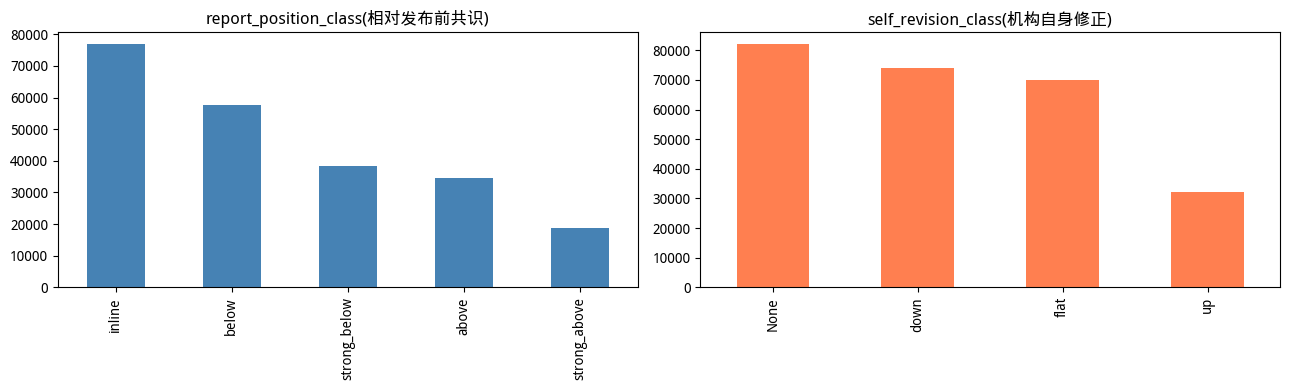

report_position_valid: {1: 226032, 0: 31884}
invalid_reason: {None: 226032, 'insufficient_pre_consensus': 31825, 'near_zero_unclassifiable': 59}
same_org_day_multiple_reports: {0: 257608, 1: 308}


In [10]:
v = rep[rep["report_position_valid"] == 1]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
v["report_position_class"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("report_position_class(相对发布前共识)")
rep["self_revision_class"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("self_revision_class(机构自身修正)")
plt.tight_layout(); plt.show()
print("report_position_valid:", rep["report_position_valid"].value_counts().to_dict())
print("invalid_reason:", rep["invalid_reason"].value_counts(dropna=False).to_dict())
print("same_org_day_multiple_reports:", rep["same_org_day_multiple_reports"].value_counts().to_dict())


## 5. QA 单元测试（V2 方案 §14）

下面把所有断言跑一遍，逐条输出 PASS/FAIL，最后汇总。


In [11]:
results = []
def check(name, cond, detail=""):
    ok = bool(cond)
    results.append((name, ok, detail))
    print(("PASS" if ok else "FAIL") + " | " + name + (("  |  " + detail) if detail else ""))


In [12]:
# ---- 纯函数单测（重实现 V2 的 transition_class）----
def transition_class(a, b, st_t, st_f, cls5):
    if pd.isna(a) or pd.isna(b):
        return None
    if st_t == "profit" and st_f == "profit":
        m = {"flat": "profit_flat", "up": "profit_up", "down": "profit_down",
             "strong_up": "profit_strong_up", "strong_down": "profit_strong_down"}
        return m.get(cls5)
    if st_t == "loss" and st_f == "loss":
        return "loss_narrowing" if b > a else ("loss_widening" if b < a else "loss_unchanged")
    if st_t == "profit" and st_f == "loss":
        return "turn_to_loss"
    if st_t in ("loss", "near_zero", "mixed_sign") and st_f == "profit":
        return "turn_to_profit"
    if "mixed_sign" in (st_t, st_f):
        return "mixed_sign_transition"
    if "near_zero" in (st_t, st_f):
        return "near_zero_transition"
    return "other"

for a, b, st, sf, cls, exp in [
    (-100, -60, "loss", "loss", None, "loss_narrowing"),
    (-100, -130, "loss", "loss", None, "loss_widening"),
    (-100, 50, "loss", "profit", None, "turn_to_profit"),
    (100, -50, "profit", "loss", None, "turn_to_loss"),
    (100, 103, "profit", "profit", "up", "profit_up"),
    (100, 103, "profit", "profit", "flat", "profit_flat"),
]:
    got = transition_class(a, b, st, sf, cls)
    check("盈亏迁移 %d->%d -> %s" % (a, b, exp), got == exp, "got %s" % got)


PASS | 盈亏迁移 -100->-60 -> loss_narrowing  |  got loss_narrowing
PASS | 盈亏迁移 -100->-130 -> loss_widening  |  got loss_widening
PASS | 盈亏迁移 -100->50 -> turn_to_profit  |  got turn_to_profit
PASS | 盈亏迁移 100->-50 -> turn_to_loss  |  got turn_to_loss
PASS | 盈亏迁移 100->103 -> profit_up  |  got profit_up
PASS | 盈亏迁移 100->103 -> profit_flat  |  got profit_flat


In [13]:
# ---- §14.9 无未来信息：快照用 <=t 记录、可复现 ----
ok = True
sample = snap[snap["snapshot_valid"] == 1].sample(3, random_state=0)
for _, r in sample.iterrows():
    t, sc, fy = r["asof_month"], r["stock_code"], r["fy"]
    sub = org_daily[(org_daily["stock_code"] == sc) & (org_daily["fy"] == fy) &
                    (org_daily["publish_date"] <= t)].copy()
    sub["age"] = (t - sub["publish_date"]).dt.days
    sub = sub.sort_values("publish_date")
    latest = sub.groupby("org_id").tail(1)
    latest = latest[latest["age"] <= 180]
    no_future = (latest["publish_date"] <= t).all()
    match = (abs(latest["forecast"].median() - r["consensus_median"]) < 1e-6) and (len(latest) == r["n_org"])
    ok &= (no_future and match)
check("无未来信息 + 快照可复现（抽 3 个有效快照重算）", ok)


PASS | 无未来信息 + 快照可复现（抽 3 个有效快照重算）


In [14]:
# ---- §14.1 180 天过期 / stale_ratio ----
ok = True
for _, r in snap[snap["snapshot_valid"] == 1].sample(3, random_state=1).iterrows():
    t, sc, fy = r["asof_month"], r["stock_code"], r["fy"]
    sub = org_daily[(org_daily["stock_code"] == sc) & (org_daily["fy"] == fy) &
                    (org_daily["publish_date"] <= t)].copy()
    sub["age"] = (t - sub["publish_date"]).dt.days
    sub = sub.sort_values("publish_date")
    cand = sub.groupby("org_id").tail(1)
    sr = float((cand["age"] > 180).mean())
    ok &= (abs(sr - r["stale_ratio"]) < 1e-9)
check("180 天过期：stale_ratio 可复现（抽 3）", ok)


PASS | 180 天过期：stale_ratio 可复现（抽 3）


In [15]:
# ---- §14.2 左删失 / P01 ----
check("历史窗口补齐 -> 快照 left_censored 全为 0", (snap["left_censored"] == 0).all())
check("未来窗口补齐 -> 修正 right_censored 全为 0", (rev["right_censored"] == 0).all())
check("future_snapshot_missing 与 right_censored 分离", rev["future_snapshot_missing"].isin([0, 1]).all())


PASS | 历史窗口补齐 -> 快照 left_censored 全为 0
PASS | 未来窗口补齐 -> 修正 right_censored 全为 0
PASS | future_snapshot_missing 与 right_censored 分离


In [16]:
# ---- §14.4 无效目标置空 ----
inv = rev[rev["revision_consensus_valid"] == 0]
check("无效主目标 pct/class 置空",
      inv["revision_consensus_pct"].isna().all() and inv["revision_consensus_class"].isna().all())
check("无效样本 profit_transition_class 置空", inv["profit_transition_class"].isna().all())
check("有效样本 profit_transition_class 非空", rev.loc[rev["revision_consensus_valid"] == 1, "profit_transition_class"].notna().all())


PASS | 无效主目标 pct/class 置空
PASS | 无效样本 profit_transition_class 置空
PASS | 有效样本 profit_transition_class 非空


In [17]:
# ---- §14.5 固定面板 / §14.6 主动修正 独立有效 ----
bad_fixed = rev[(rev["revision_consensus_valid"] == 1) & (rev["n_org_fixed"] < 3)]
check("交集<3 时 fixed_valid=0 且 fixed_pct 置空 (n=%d)" % len(bad_fixed),
      (bad_fixed["revision_fixed_valid"] == 0).all() and bad_fixed["revision_fixed_pct"].isna().all())
low_act = rev[rev["n_active_update"] < 3]
check("主动<3 时 active/breadth 置空 (n=%d)" % len(low_act),
      (low_act["revision_active_valid"] == 0).all() and low_act["revision_active_pct"].isna().all()
      and low_act["revision_breadth"].isna().all() and low_act["revision_active_class"].isna().all())
check("breadth_valid 与 revision_active_valid 一致", (rev["breadth_valid"] == rev["revision_active_valid"]).all())


PASS | 交集<3 时 fixed_valid=0 且 fixed_pct 置空 (n=116)
PASS | 主动<3 时 active/breadth 置空 (n=137248)
PASS | breadth_valid 与 revision_active_valid 一致


In [18]:
# ---- §14.3 同日多报告不合并 + P05 ----
multi = rep_raw[rep_raw["same_org_day_multiple_reports"] == 1]
if len(multi):
    nrep = multi.groupby(["stock_code", "fy", "org_id", "publish_date"])["source_report_id"].nunique()
    check("同日多报告保留真实多行（组数=%d）" % len(nrep), (nrep >= 2).all())
    od24 = org_daily[(org_daily["publish_date"] >= "2024-01-01") & (org_daily["publish_date"] <= "2024-12-31")]
    check("机构日终已标记 org_day_aggregate=1（2024 范围一致）",
          int((od24["org_day_aggregate"] == 1).sum()) == len(nrep))
else:
    check("同日多报告：无冲突样本（跳过）", True, "no conflict found")


PASS | 同日多报告保留真实多行（组数=154）


PASS | 机构日终已标记 org_day_aggregate=1（2024 范围一致）


In [19]:
# ---- P06/P14 ID 稳定性 ----
check("stock_code 为 6 位字符串", rep["stock_code"].astype(str).str.match(r"^\d{6}$").all())
check("report_signature 为 sha256(64hex)", rep["report_signature"].astype(str).str.match(r"^[0-9a-f]{64}$").all())
check("source_report_id 保留", rep["source_report_id"].notna().all())


PASS | stock_code 为 6 位字符串


PASS | report_signature 为 sha256(64hex)
PASS | source_report_id 保留


In [20]:
# ---- §14.8 训练期阈值一致（用快照表重算比对元数据）----
TRAIN_END = pd.Timestamp("2024-06-30")
train = snap[snap["asof_month"] <= TRAIN_END]

# near_zero 阈值
sr = train.groupby("forecast_horizon")["consensus_median"].apply(lambda x: float(np.median(np.abs(x))))
nz = {h: 0.01 * float(sr.get(h, 0.0)) for h in [0, 1, 2]}
meta_nz = {int(k): v for k, v in meta["near_zero_threshold"].items()}
check("near_zero 阈值可复现", all(abs(nz.get(h, 0) - meta_nz.get(h, 0)) < 1e-6 for h in [0, 1, 2]))

# 共识强度 q30/q70
q = {}
for h in [0, 1, 2]:
    d = train[(train["forecast_horizon"] == h) & (train["n_org"] >= 5) &
              (train["profit_state"].isin(["profit", "loss"]))]["dispersion_robust"].dropna()
    q[h] = (float(d.quantile(0.30)), float(d.quantile(0.70)))
meta_q = {int(k): tuple(v) for k, v in meta["consensus_strength_q30_q70"].items()}
check("共识强度 q30/q70 可复现", all(
    abs(q[h][0] - meta_q[h][0]) < 1e-6 and abs(q[h][1] - meta_q[h][1]) < 1e-6 for h in [0, 1, 2]))


PASS | near_zero 阈值可复现
PASS | 共识强度 q30/q70 可复现


In [21]:
# ---- QA 汇总 ----
n_pass = sum(1 for _, ok, _ in results if ok)
n_fail = len(results) - n_pass
print("=" * 60)
print("QA 汇总: %d 项检查, PASS %d, FAIL %d" % (len(results), n_pass, n_fail))
if n_fail:
    print("\n失败项:")
    for name, ok, detail in results:
        if not ok:
            print("  FAIL |", name, "|", detail)


QA 汇总: 24 项检查, PASS 24, FAIL 0


## 6. QA 图表（V2 方案 §15）


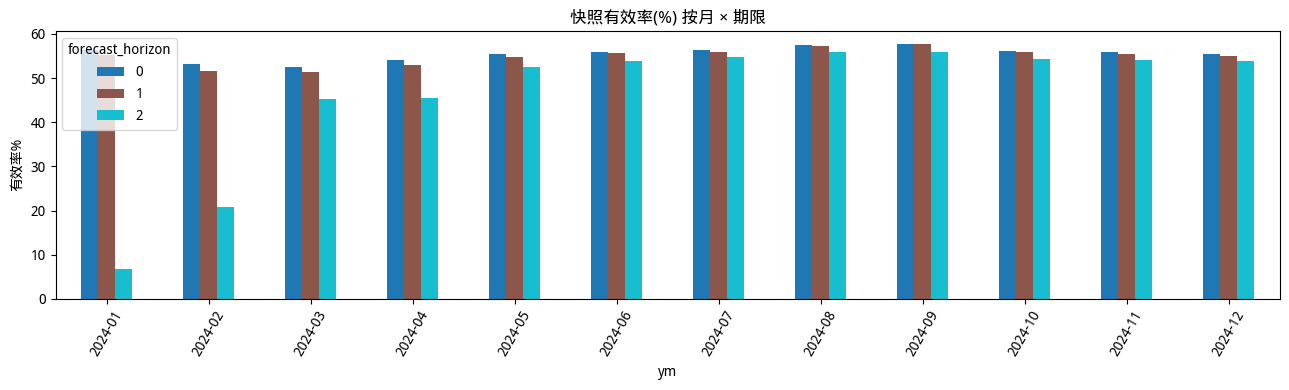

In [22]:
# 快照有效率：月份 × 期限
s = snap.copy()
s["ym"] = s["asof_month"].dt.strftime("%Y-%m")
tbl = s.groupby(["ym", "forecast_horizon"]).agg(
    total=("snapshot_valid", "size"),
    valid=("snapshot_valid", "sum")).reset_index()
tbl["rate"] = (tbl["valid"] / tbl["total"] * 100).round(1)
piv = tbl.pivot_table(index="ym", columns="forecast_horizon", values="rate")
piv.plot(kind="bar", figsize=(13, 4), colormap="tab10")
plt.title("快照有效率(%) 按月 × 期限"); plt.ylabel("有效率%"); plt.xticks(rotation=60)
plt.tight_layout(); plt.show()


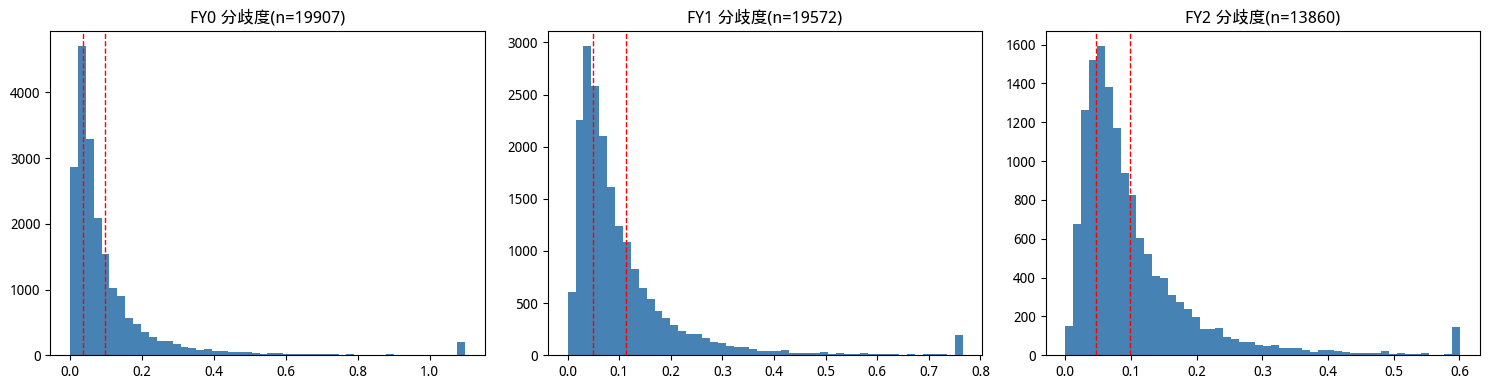

In [23]:
# 分歧度分布：只画有效样本，按期限，标出训练期 q30/q70
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, h in enumerate([0, 1, 2]):
    d = snap[(snap["snapshot_valid"] == 1) & (snap["forecast_horizon"] == h)]["dispersion_robust"]
    axes[i].hist(d.clip(0, d.quantile(0.99)), bins=50, color="steelblue")
    q30, q70 = meta["consensus_strength_q30_q70"][str(h)]
    axes[i].axvline(q30, color="red", ls="--", lw=1); axes[i].axvline(q70, color="red", ls="--", lw=1)
    axes[i].set_title("FY%d 分歧度(n=%d)" % (h, len(d)))
plt.tight_layout(); plt.show()


In [24]:
# 修正类别：target_horizon × forecast_horizon
v = rev[rev["revision_consensus_valid"] == 1]
ct = pd.crosstab([v["target_horizon_months"], v["forecast_horizon"]], v["revision_consensus_class"])
print("普通修正五分类 按(期限×FY):")
print(ct)
print("\n连续修正分位数(revision_consensus_pct):")
print(v["revision_consensus_pct"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(3).to_string())


普通修正五分类 按(期限×FY):
revision_consensus_class                down   flat  strong_down  strong_up    up
target_horizon_months forecast_horizon                                           
1                     0                 4632  10320         1718        248  1406
                      1                 4732  10087         1729        242  1667
                      2                 1948   8386         1658        482   964
3                     0                 6913   6053         2327        274  1681
                      1                 7196   5920         2268        237  1927
                      2                 3622   5283         1979        407  1420

连续修正分位数(revision_consensus_pct):
0.05   -0.260
0.25   -0.053
0.50   -0.006
0.75    0.000
0.95    0.050


In [25]:
# 盈亏状态迁移矩阵 profit_state × future 状态（静态对照）
v = rev[rev["revision_consensus_valid"] == 1]
# 用 transition 类别看迁移
tr = v["profit_transition_class"].value_counts()
print("盈亏迁移类别计数:")
print(tr.to_string())


盈亏迁移类别计数:
profit_flat              46049
profit_down              29043
profit_strong_down       11679
profit_up                 9065
mixed_sign_transition     1983
profit_strong_up          1890
loss_widening              333
loss_narrowing             216
loss_unchanged             115
turn_to_profit              93
near_zero_transition         3


固定面板与市场共识方向一致率: 73.49%


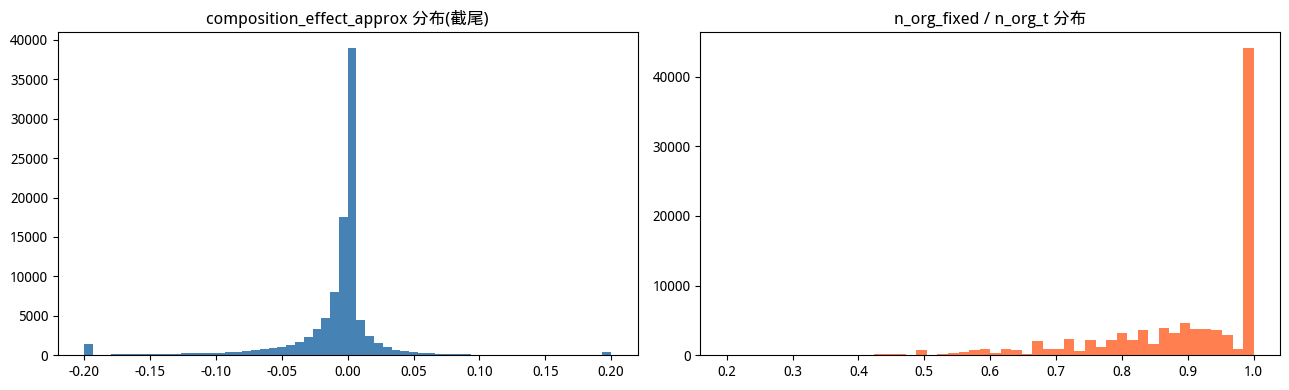

In [26]:
# 固定面板 vs 市场共识 方向一致率 + composition_effect_approx 分布
v = rev[(rev["revision_consensus_valid"] == 1) & (rev["revision_fixed_valid"] == 1)].copy()
agree = np.sign(v["revision_consensus_pct"]) == np.sign(v["revision_fixed_pct"])
print("固定面板与市场共识方向一致率: %.2f%%" % (agree.mean() * 100))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(v["composition_effect_approx"].clip(-0.2, 0.2), bins=60, color="steelblue")
axes[0].set_title("composition_effect_approx 分布(截尾)")
axes[1].hist(v["n_org_fixed"] / v["n_org_t"].clip(lower=1), bins=50, color="coral")
axes[1].set_title("n_org_fixed / n_org_t 分布")
plt.tight_layout(); plt.show()
